# Modelling — Mortgage Default PD (IFRS-9)

Pipeline: Dummy → Logistic → LDA → Naive Bayes → Decision Tree → Random Forest → XGBoost

Sampling strategy comparison: `class_weight` vs SMOTE vs ADASYN

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)

# Sampling
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed — skipping XGB. Run: pip install xgboost")

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed — skipping SHAP. Run: pip install shap")

import joblib, pickle


## Load Data

In [2]:
BASE = r"C:\\Users\\Niraj Mhatre\\projects\\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\\notebooks\\"

# BUG FIX: original loaded test_df.csv into train_df (copy-paste error)
train_df = pd.read_csv(BASE + "train_df.csv")
val_df   = pd.read_csv(BASE + "val_df.csv")
test_df  = pd.read_csv(BASE + "test_df.csv")


print("Shapes — train:", train_df.shape, "| val:", val_df.shape, "| test:", test_df.shape)


Shapes — train: (350000, 21) | val: (50000, 21) | test: (150000, 21)


## Feature / Target Split

In [3]:
TARGET = "defaulted_flag"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_val   = val_df.drop(columns=[TARGET])
y_val   = val_df[TARGET]
X_test  = test_df.drop(columns=[TARGET])
y_test  = test_df[TARGET]


for name, X in [("X_train", X_train), ("X_val", X_val), ("X_test", X_test)]:
    assert X.isna().sum().sum() == 0, f"{name} has NaNs — re-run feature engineering"
    assert np.isinf(X.select_dtypes(include=[np.number])).sum().sum() == 0, f"{name} has Infs"
print("All splits clean: 0 NaN, 0 Inf")


All splits clean: 0 NaN, 0 Inf


In [4]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((350000, 20), (350000,), (50000, 20), (50000,), (150000, 20), (150000,))

In [5]:
y_val.value_counts()

defaulted_flag
0    45521
1     4479
Name: count, dtype: int64

## Class Imbalance Analysis

**Why this matters for IFRS-9**: Under-sampling or ignoring imbalance causes PD models to systematically under-predict default probabilities on stressed cohorts. The ECL (Expected Credit Loss = PD × LGD × EAD) is then understated. Recall on the minority class (actual defaults) is the metric that matters most — missing a true default has far higher cost than a false alarm.

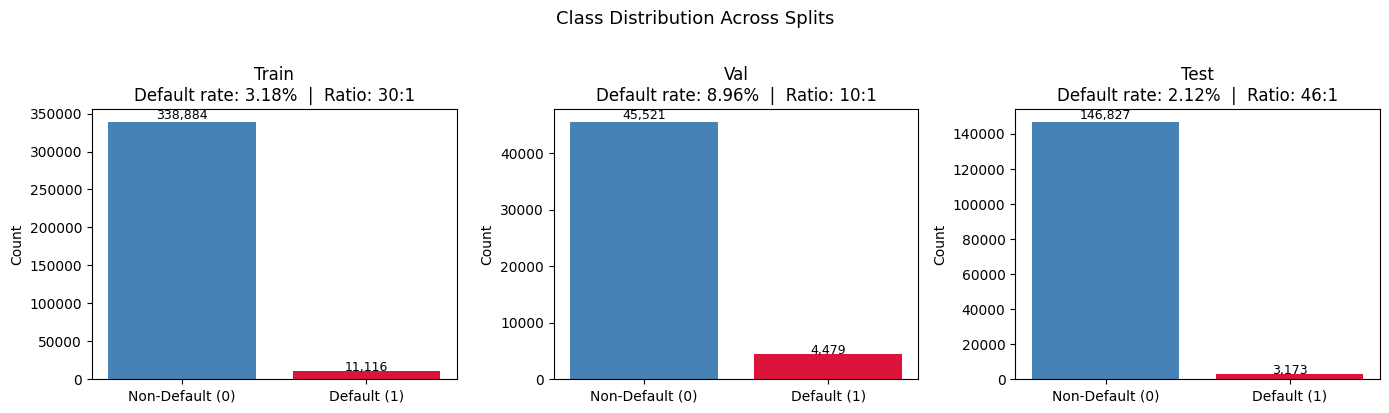


Train: 11,116 defaults / 350,000 total (3.18%) — ratio 30.5:1
Val  : 4,479 defaults / 50,000 total (8.96%)
Test : 3,173 defaults / 150,000 total (2.12%)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nm, df) in zip(axes, [("Train", train_df), ("Val", val_df), ("Test", test_df)]):
    counts = df[TARGET].value_counts()
    pos = counts.get(1, 0)
    neg = counts.get(0, 0)
    ax.bar(["Non-Default (0)", "Default (1)"], [neg, pos], color=["steelblue", "crimson"])
    ax.set_title(f"{nm}\nDefault rate: {pos/len(df):.2%}  |  Ratio: {neg/pos:.0f}:1")
    ax.set_ylabel("Count")
    for bar, val in zip(ax.patches, [neg, pos]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{val:,}", ha="center", fontsize=9)
plt.suptitle("Class Distribution Across Splits", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTrain: {y_train.sum():,} defaults / {len(y_train):,} total "
      f"({y_train.mean():.2%}) — ratio {(1-y_train.mean())/y_train.mean():.1f}:1")
print(f"Val  : {y_val.sum():,} defaults / {len(y_val):,} total "
      f"({y_val.mean():.2%})")
print(f"Test : {y_test.sum():,} defaults / {len(y_test):,} total "
      f"({y_test.mean():.2%})")


## Sampling Strategy

At 30:1 imbalance three approaches are compared:

| Strategy | Mechanism | IFRS-9 Note |
|---|---|---|
| `class_weight='balanced'` | Re-weights the loss function — no synthetic data | Fastest; PD outputs require Platt scaling recalibration |
| **SMOTE** | Synthetic Minority Over-sampling in feature space | Industry standard; can create unrealistic loan profiles |
| **ADASYN** | SMOTE variant that focuses on hard-to-classify boundary samples | Better recall on hardest defaults; noisier |

> **Key principle**: SMOTE / ADASYN are applied **only to the training set**. Val and test sets are **never resampled** — they must reflect the real population for valid PD calibration. This is an IFRS-9 model risk requirement.

> **Chosen strategy**: SMOTE with `sampling_strategy=0.2` (1 default per 5 non-defaults = 5:1 ratio). Full 1:1 oversampling is excessive for tree models and hurts PD calibration.

In [7]:
# ── Sampling strategy: only on TRAIN ──────────────────────────────────────────
# Val and test are NEVER resampled — they reflect the real population

# Strategy 1: class_weight (no synthetic data)
# Applied directly inside model constructors below — no separate dataset needed.

# Strategy 2: SMOTE
smote = SMOTE(
    sampling_strategy=0.2,   # minority:majority = 1:5 after resampling (was 1:30)
    random_state=143,
    k_neighbors=5
)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
print(f"SMOTE: {X_train_smote.shape[0]:,} rows | "
      f"default rate: {y_train_smote.mean():.2%} | "
      f"ratio: {(1-y_train_smote.mean())/y_train_smote.mean():.1f}:1")

# Strategy 3: ADASYN
adasyn = ADASYN(
    sampling_strategy=0.2,
    random_state=42,
    n_neighbors=5
)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)
print(f"ADASYN: {X_train_adasyn.shape[0]:,} rows | "
      f"default rate: {y_train_adasyn.mean():.2%} | "
      f"ratio: {(1-y_train_adasyn.mean())/y_train_adasyn.mean():.1f}:1")


SMOTE: 406,660 rows | default rate: 16.67% | ratio: 5.0:1
ADASYN: 408,765 rows | default rate: 17.10% | ratio: 4.8:1


## Evaluation Utility

In [8]:
RESULTS = {}   # accumulates {model_name: {split: metrics}}

def evaluate(model, X, y, model_name, split_name="Val", threshold=0.5, store=True):
    """
    Compute and display classification metrics.
    Uses PR-AUC alongside ROC-AUC because PR-AUC is more informative under
    severe class imbalance (ROC-AUC can look good even with poor recall).
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "Accuracy" : accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall"   : recall_score(y, y_pred, zero_division=0),
        "F1"       : f1_score(y, y_pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y, y_prob),
        "PR-AUC"   : average_precision_score(y, y_prob),
    }

    if store:
        RESULTS.setdefault(model_name, {})[split_name] = metrics

    print(f"\n{'='*60}")
    print(f"  {model_name}  [{split_name}]  (threshold={threshold})")
    print(f"{'='*60}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print()
    print(classification_report(y, y_pred, zero_division=0,
                                target_names=["Non-Default", "Default"]))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred, ax=axes[0],
        display_labels=["Non-Default", "Default"], colorbar=False)
    axes[0].set_title("Confusion Matrix")

    RocCurveDisplay.from_predictions(y, y_prob, ax=axes[1])
    axes[1].plot([0,1],[0,1],'k--', lw=0.8); axes[1].set_title("ROC Curve")

    PrecisionRecallDisplay.from_predictions(y, y_prob, ax=axes[2])
    axes[2].axhline(y.mean(), color='r', linestyle='--', label=f'Baseline ({y.mean():.2%})')
    axes[2].legend(); axes[2].set_title("Precision-Recall Curve")

    plt.suptitle(f"{model_name} — {split_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

    return metrics


## 1. Dummy Classifier (Baseline)


  Dummy  [Val]  (threshold=0.5)
  Accuracy    : 0.9104
  Precision   : 0.0000
  Recall      : 0.0000
  F1          : 0.0000
  ROC-AUC     : 0.5000
  PR-AUC      : 0.0896

              precision    recall  f1-score   support

 Non-Default       0.91      1.00      0.95     45521
     Default       0.00      0.00      0.00      4479

    accuracy                           0.91     50000
   macro avg       0.46      0.50      0.48     50000
weighted avg       0.83      0.91      0.87     50000



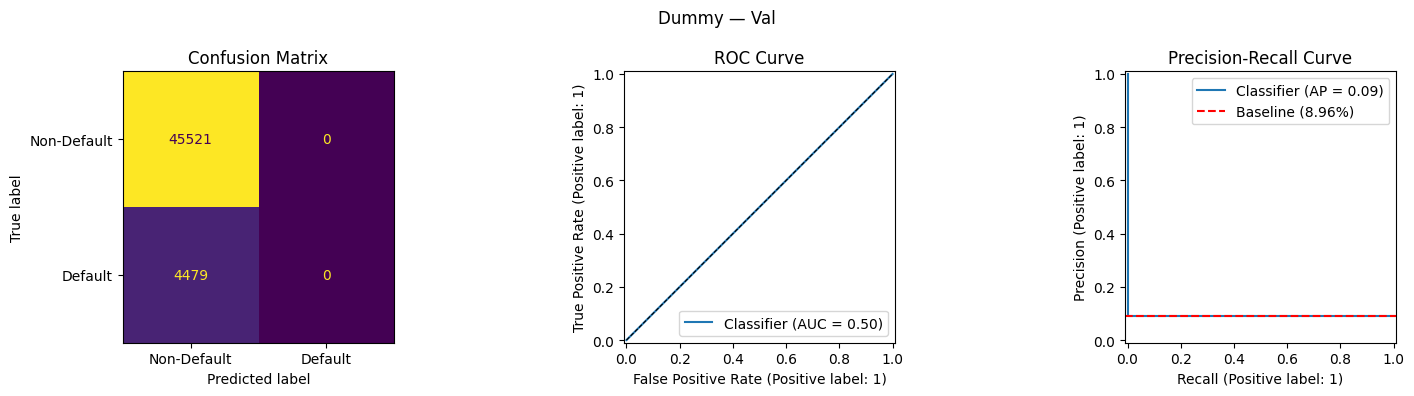

{'Accuracy': 0.91042,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1': 0.0,
 'ROC-AUC': 0.5,
 'PR-AUC': 0.08958}

In [9]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
evaluate(dummy, X_val, y_val, model_name="Dummy", split_name="Val")


## 2. Logistic Regression

Three variants compared — balanced weights, SMOTE, ADASYN — to isolate the effect of sampling strategy on PD recall.

checking assumptions before running logistic

                       Feature        VIF
17      credit_ltv_interaction  70.741403
5                       og_ltv  66.799807
18        dti_rate_interaction  57.799257
3                       og_dti  54.048556
16         dti_ltv_interaction  22.588301
6                  og_int_rate   9.844541
0                   cred_score   7.338472
8                     MSA_freq   1.736422
1   mortgage_insurance_percent   1.581865
13           servicer_name_woe   1.495924
14             seller_name_woe   1.402879
4                       og_upb   1.212465
19                        FTHB   1.169400
10            loan_purpose_woe   1.088915
12              prop_state_woe   1.075282
11                 channel_woe   1.066155
15              cltv_ltv_ratio   1.058877
7              no_of_borrowers   1.038596
9                prop_type_woe   1.020018
2                      unit_no   1.005002


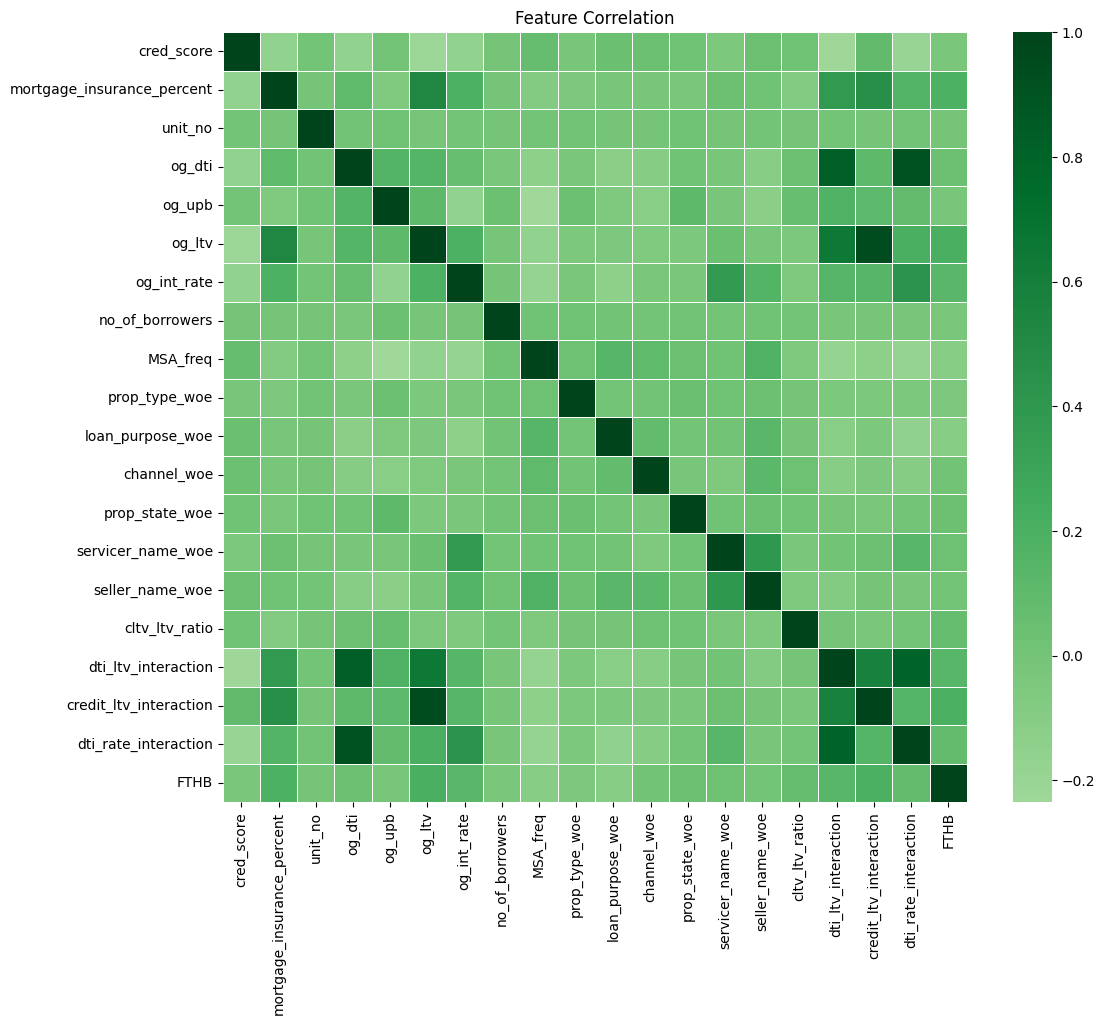

In [10]:
#corr and vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
correlation = X_train.corr()
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data.sort_values("VIF", ascending=False))
plt.figure(figsize=(12,10))
sns.heatmap(correlation, cmap="Greens", center=0, linewidths=0.5)
plt.title("Feature Correlation")
plt.show()

vif and corr checks passed

boxplots

<Axes: >

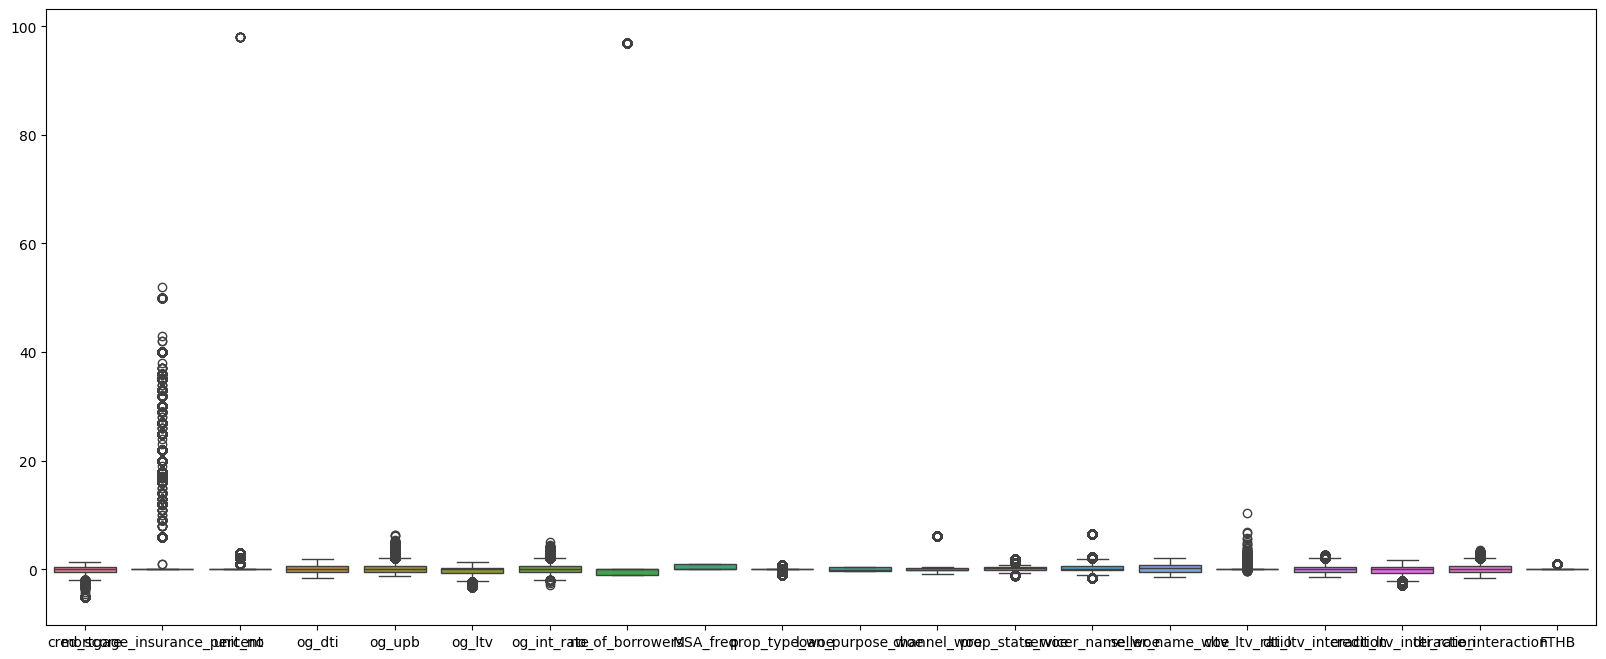

In [11]:
plt.figure(figsize=(20, 8))
sns.boxplot(X_train)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def logit_plot(X_train, feature, target, bins=20):
    temp = X_train[[feature, target]].copy()

    temp['bin'] = pd.qcut(temp[feature], q=bins, duplicates='drop')

    grouped = temp.groupby('bin')[target].mean()

    x = temp.groupby('bin')[feature].mean()

    # Avoid 0 and 1 probabilities
    p = grouped.clip(0.001, 0.999)

    log_odds = np.log(p/(1-p))

    plt.figure(figsize=(7,5))
    plt.scatter(x, log_odds)
    plt.plot(x, log_odds)
    plt.xlabel(feature)
    plt.ylabel("Log Odds")
    plt.title(f"{feature} vs Log Odds")
    plt.grid(True)
    plt.show()

checking linearity of log odds

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# X = dataframe containing only continuous variables
X_bt = X_train.copy()

# Ensure all values are positive
for col in X_bt.columns:
    min_val = X_bt[col].min()
    if min_val <= 0:
        X_bt[col] = X_bt[col] - min_val + 1

# Create interaction term X * log(X)
for col in X_bt.columns:
    X_bt[col + "_log"] = X_bt[col] * np.log(X_bt[col])

X_bt = sm.add_constant(X_bt)

model = sm.Logit(y_train, X_bt)
result = model.fit()

print(result.summary())

         Current function value: 0.112502
         Iterations: 35


c:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                           Logit Regression Results                           
Dep. Variable:         defaulted_flag   No. Observations:               350000
Model:                          Logit   Df Residuals:                   349959
Method:                           MLE   Df Model:                           40
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.2010
Time:                        06:44:59   Log-Likelihood:                -39376.
converged:                      False   LL-Null:                       -49283.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                            -18.1519        nan        nan        nan         nan         nan
cred_score                         5.0246      1.245      4.035      0.


  LR (class_weight)  [Val]  (threshold=0.8)
  Accuracy    : 0.8171
  Precision   : 0.2307
  Recall      : 0.4461
  F1          : 0.3041
  ROC-AUC     : 0.7463
  PR-AUC      : 0.2155

              precision    recall  f1-score   support

 Non-Default       0.94      0.85      0.89     45521
     Default       0.23      0.45      0.30      4479

    accuracy                           0.82     50000
   macro avg       0.59      0.65      0.60     50000
weighted avg       0.88      0.82      0.84     50000



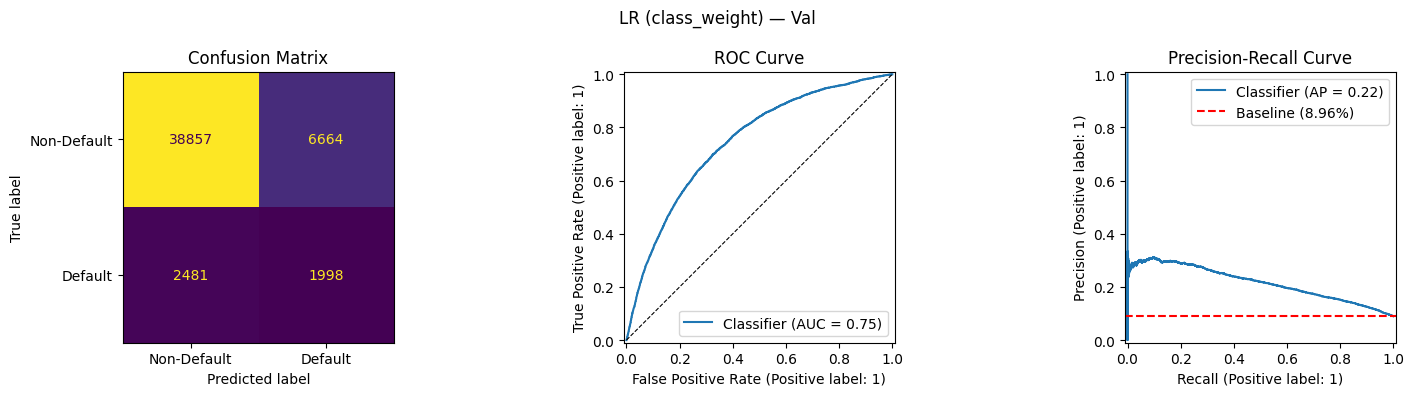

{'Accuracy': 0.8171,
 'Precision': 0.23066266451166012,
 'Recall': 0.44608171466845276,
 'F1': 0.30408644699794535,
 'ROC-AUC': 0.7462990113143131,
 'PR-AUC': 0.21553105875811826}

In [14]:
# ── 2a. Balanced class_weight (no synthetic data) ──────────────────────────
lr_cw = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42, solver="lbfgs"
)
lr_cw.fit(X_train, y_train)
evaluate(lr_cw, X_val, y_val, model_name="LR (class_weight)", threshold=0.8, split_name="Val")



  LR (SMOTE)  [Val]  (threshold=0.5)
  Accuracy    : 0.8437
  Precision   : 0.2460
  Recall      : 0.3610
  F1          : 0.2926
  ROC-AUC     : 0.7424
  PR-AUC      : 0.2140

              precision    recall  f1-score   support

 Non-Default       0.93      0.89      0.91     45521
     Default       0.25      0.36      0.29      4479

    accuracy                           0.84     50000
   macro avg       0.59      0.63      0.60     50000
weighted avg       0.87      0.84      0.86     50000



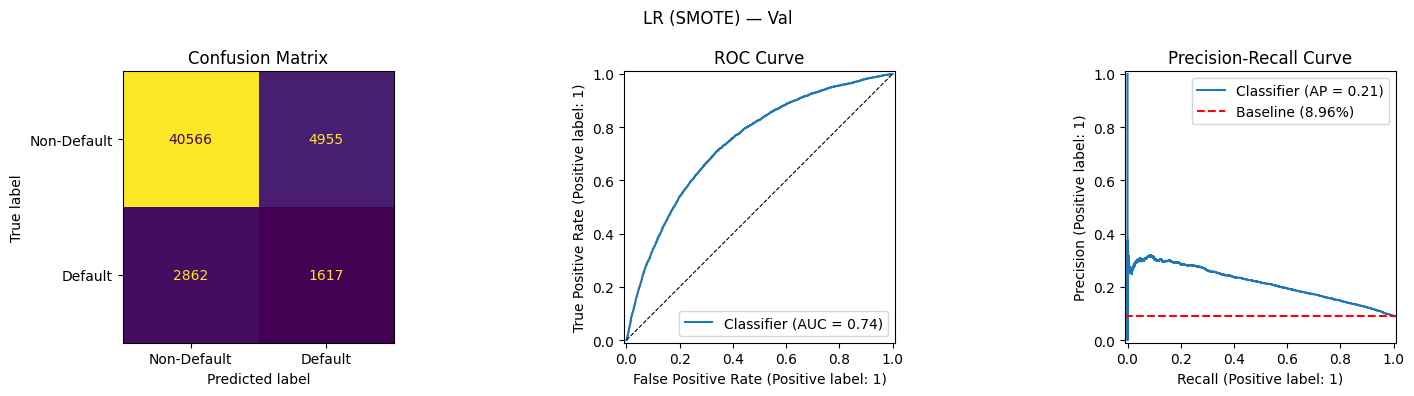

{'Accuracy': 0.84366,
 'Precision': 0.2460438222763238,
 'Recall': 0.3610180843938379,
 'F1': 0.29264319971043345,
 'ROC-AUC': 0.7424133347276245,
 'PR-AUC': 0.21397035816443874}

In [15]:
# ── 2b. SMOTE ──────────────────────────────────────────────────────────────
lr_smote = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
lr_smote.fit(X_train_smote, y_train_smote)
evaluate(lr_smote, X_val, y_val, model_name="LR (SMOTE)",threshold = 0.5, split_name="Val")



  LR (ADASYN)  [Val]  (threshold=0.5)
  Accuracy    : 0.8417
  Precision   : 0.2429
  Recall      : 0.3621
  F1          : 0.2907
  ROC-AUC     : 0.7417
  PR-AUC      : 0.2124

              precision    recall  f1-score   support

 Non-Default       0.93      0.89      0.91     45521
     Default       0.24      0.36      0.29      4479

    accuracy                           0.84     50000
   macro avg       0.59      0.63      0.60     50000
weighted avg       0.87      0.84      0.86     50000



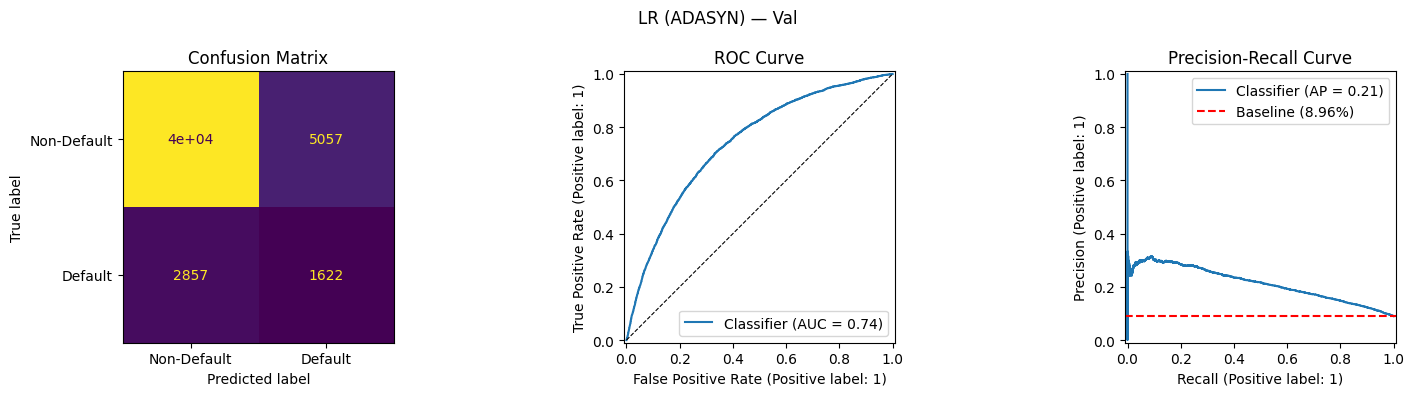

{'Accuracy': 0.84172,
 'Precision': 0.24285072615661027,
 'Recall': 0.3621344050011163,
 'F1': 0.2907331062914501,
 'ROC-AUC': 0.7416817488027859,
 'PR-AUC': 0.21235635969247105}

In [16]:
# ── 2c. ADASYN ─────────────────────────────────────────────────────────────
lr_adasyn = LogisticRegression(max_iter=1000, random_state=42, solver="lbfgs")
lr_adasyn.fit(X_train_adasyn, y_train_adasyn)
evaluate(lr_adasyn, X_val, y_val, model_name="LR (ADASYN)", split_name="Val")


## 3. Linear Discriminant Analysis

LDA has no `class_weight` parameter — imbalance is addressed via `priors`. LDA is trained on SMOTE data for comparability.


  LDA  [Val]  (threshold=0.34)
  Accuracy    : 0.9023
  Precision   : 0.3187
  Recall      : 0.0793
  F1          : 0.1269
  ROC-AUC     : 0.7468
  PR-AUC      : 0.2198

              precision    recall  f1-score   support

 Non-Default       0.92      0.98      0.95     45521
     Default       0.32      0.08      0.13      4479

    accuracy                           0.90     50000
   macro avg       0.62      0.53      0.54     50000
weighted avg       0.86      0.90      0.87     50000



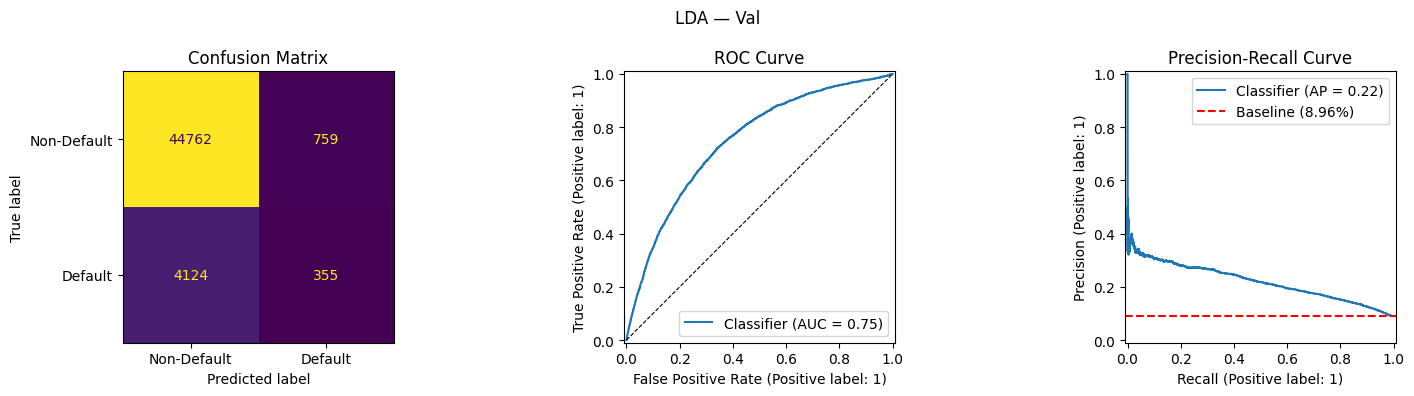

{'Accuracy': 0.90234,
 'Precision': 0.31867145421903054,
 'Recall': 0.07925876311676713,
 'F1': 0.12694439477918826,
 'ROC-AUC': 0.7467575117836799,
 'PR-AUC': 0.21979403399769523}

In [17]:
pos_rate = y_train.mean()
lda = LinearDiscriminantAnalysis(priors=[1 - pos_rate, pos_rate])
lda.fit(X_train, y_train)
evaluate(lda, X_val, y_val, model_name="LDA",threshold = 0.34, split_name="Val")


## 4. Gaussian Naive Bayes


  Naive Bayes (SMOTE)  [Val]  (threshold=0.5)
  Accuracy    : 0.4734
  Precision   : 0.1215
  Recall      : 0.7828
  F1          : 0.2103
  ROC-AUC     : 0.6741
  PR-AUC      : 0.1719

              precision    recall  f1-score   support

 Non-Default       0.95      0.44      0.60     45521
     Default       0.12      0.78      0.21      4479

    accuracy                           0.47     50000
   macro avg       0.54      0.61      0.41     50000
weighted avg       0.88      0.47      0.57     50000



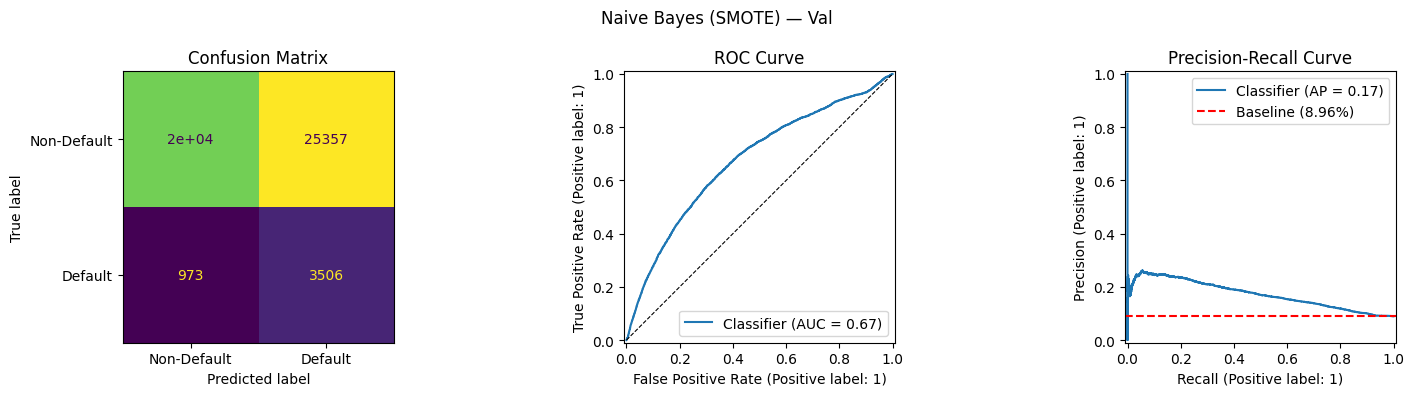

{'Accuracy': 0.4734,
 'Precision': 0.12147039462287358,
 'Recall': 0.7827640098236214,
 'F1': 0.21030532061663967,
 'ROC-AUC': 0.6741043866026832,
 'PR-AUC': 0.17190581772105878}

In [18]:
# NB has no class_weight — use SMOTE data
nb = GaussianNB(var_smoothing=1e-9)
nb.fit(X_train_smote, y_train_smote)
evaluate(nb, X_val, y_val, model_name="Naive Bayes (SMOTE)", split_name="Val")


## 5. Decision Tree


  Decision Tree  [Val]  (threshold=0.5)
  Accuracy    : 0.5446
  Precision   : 0.1374
  Recall      : 0.7736
  F1          : 0.2333
  ROC-AUC     : 0.7069
  PR-AUC      : 0.1680

              precision    recall  f1-score   support

 Non-Default       0.96      0.52      0.68     45521
     Default       0.14      0.77      0.23      4479

    accuracy                           0.54     50000
   macro avg       0.55      0.65      0.45     50000
weighted avg       0.89      0.54      0.64     50000



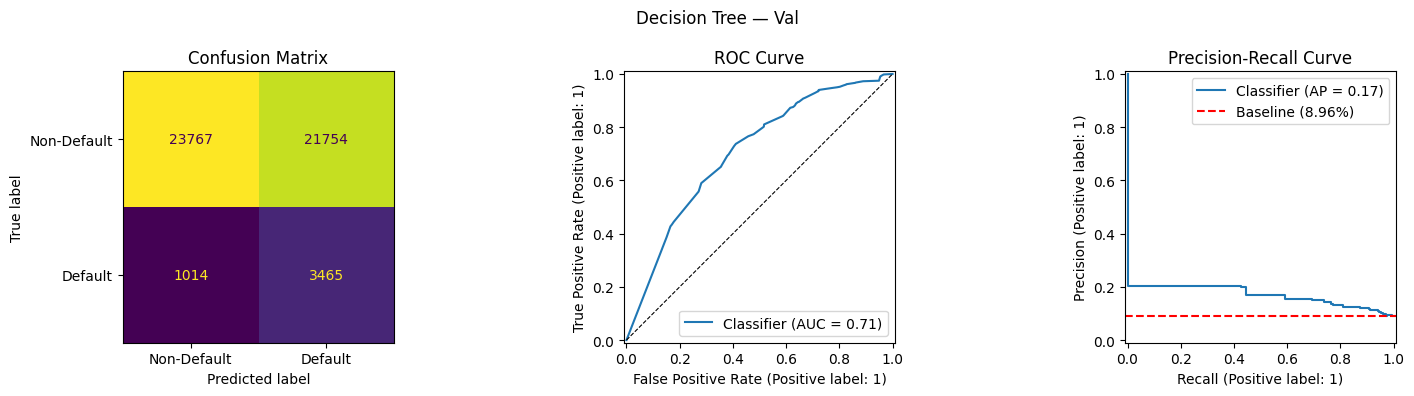

{'Accuracy': 0.54464,
 'Precision': 0.13739640747055792,
 'Recall': 0.7736101808439384,
 'F1': 0.23334904707387702,
 'ROC-AUC': 0.7069073233285248,
 'PR-AUC': 0.16798163037753538}

In [19]:
dt = DecisionTreeClassifier(
    max_depth=6, min_samples_leaf=200,
    class_weight="balanced", random_state=42
)
dt.fit(X_train, y_train)
evaluate(dt, X_val, y_val, model_name="Decision Tree", split_name="Val")


## 6. Random Forest


  Random Forest  [Val]  (threshold=0.5)
  Accuracy    : 0.5277
  Precision   : 0.1415
  Recall      : 0.8428
  F1          : 0.2423
  ROC-AUC     : 0.7488
  PR-AUC      : 0.2352

              precision    recall  f1-score   support

 Non-Default       0.97      0.50      0.66     45521
     Default       0.14      0.84      0.24      4479

    accuracy                           0.53     50000
   macro avg       0.56      0.67      0.45     50000
weighted avg       0.90      0.53      0.62     50000



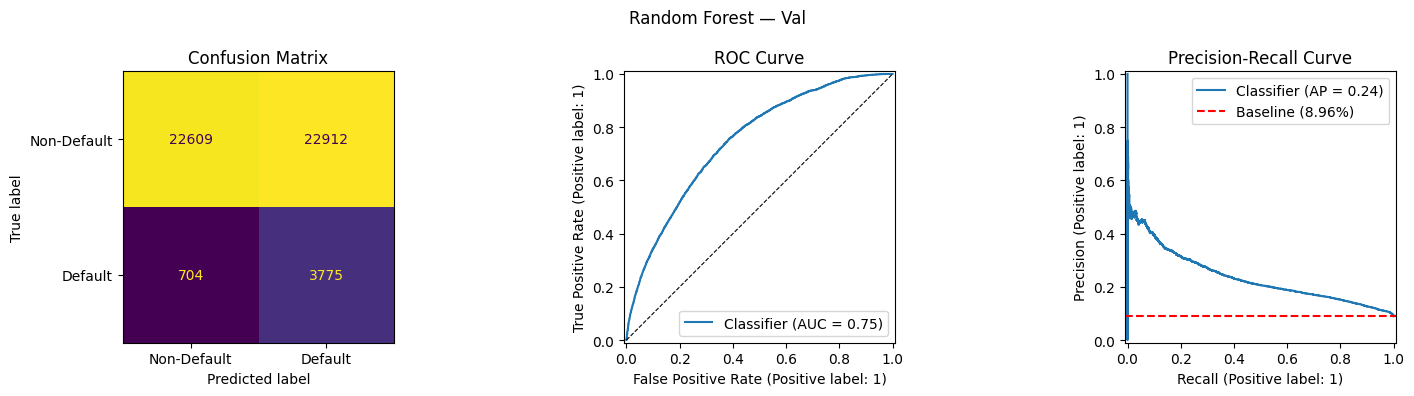

{'Accuracy': 0.52768,
 'Precision': 0.14145464083636228,
 'Recall': 0.8428220584951999,
 'F1': 0.24225117114804595,
 'ROC-AUC': 0.7488472612139065,
 'PR-AUC': 0.23519088441724725}

In [20]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=100,
    class_weight="balanced_subsample",
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
evaluate(rf, X_val, y_val, model_name="Random Forest", split_name="Val")


## 7. XGBoost

`scale_pos_weight = n_neg / n_pos` is XGBoost's native imbalance handler. Equivalent to `class_weight='balanced'` in sklearn. No synthetic data needed.


  XGBoost  [Val]  (threshold=0.5)
  Accuracy    : 0.5602
  Precision   : 0.1506
  Recall      : 0.8428
  F1          : 0.2556
  ROC-AUC     : 0.7739
  PR-AUC      : 0.2789

              precision    recall  f1-score   support

 Non-Default       0.97      0.53      0.69     45521
     Default       0.15      0.84      0.26      4479

    accuracy                           0.56     50000
   macro avg       0.56      0.69      0.47     50000
weighted avg       0.90      0.56      0.65     50000



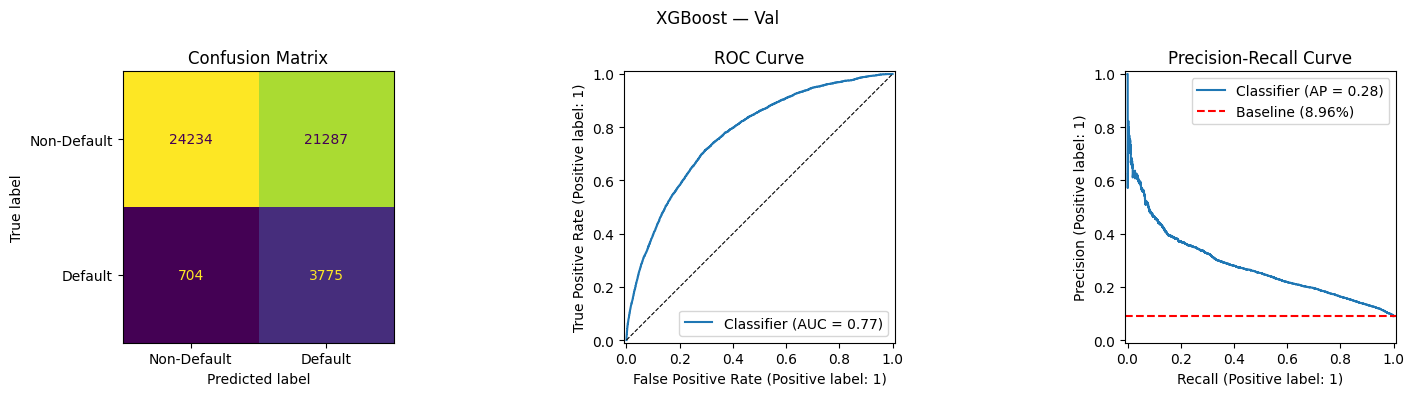

In [21]:
if XGB_AVAILABLE:
    spw = (len(y_train) - y_train.sum()) / y_train.sum()
    xgb = XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        scale_pos_weight=spw,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric="aucpr",   # PR-AUC more relevant under imbalance than logloss
        random_state=42, n_jobs=-1, verbosity=0,
        early_stopping_rounds=30,
    )
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    evaluate(xgb, X_val, y_val, model_name="XGBoost", split_name="Val")
else:
    print("XGBoost not available — skipping.")


## Model Comparison — Validation Set

              Model   Recall  Precision       F1  ROC-AUC   PR-AUC
            XGBoost 0.842822   0.150626 0.255577 0.773936 0.278895
      Random Forest 0.842822   0.141455 0.242251 0.748847 0.235191
                LDA 0.079259   0.318671 0.126944 0.746758 0.219794
  LR (class_weight) 0.446082   0.230663 0.304086 0.746299 0.215531
         LR (SMOTE) 0.361018   0.246044 0.292643 0.742413 0.213970
        LR (ADASYN) 0.362134   0.242851 0.290733 0.741682 0.212356
      Decision Tree 0.773610   0.137396 0.233349 0.706907 0.167982
Naive Bayes (SMOTE) 0.782764   0.121470 0.210305 0.674104 0.171906
              Dummy 0.000000   0.000000 0.000000 0.500000 0.089580


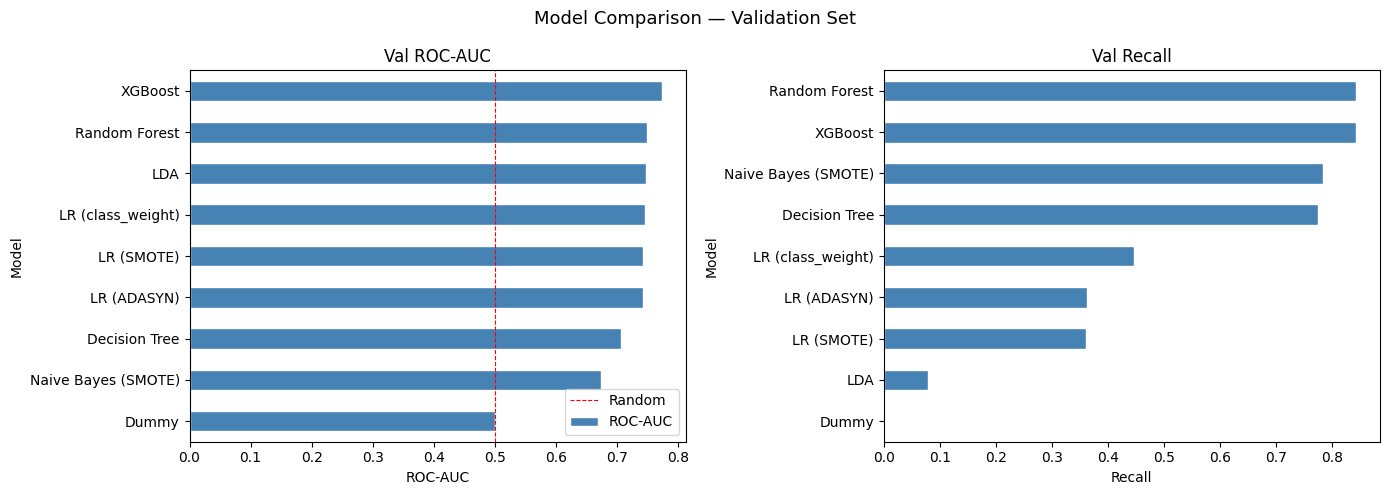


> For IFRS-9: prioritise Recall (catch more true defaults) and PR-AUC.
> ROC-AUC can be misleading under severe imbalance.


In [22]:
summary_rows = []
for model_name, splits in RESULTS.items():
    for split_name, metrics in splits.items():
        summary_rows.append({"Model": model_name, "Split": split_name, **metrics})

summary = pd.DataFrame(summary_rows)
val_summary = summary[summary["Split"] == "Val"].sort_values("ROC-AUC", ascending=False)
print(val_summary[["Model","Recall","Precision","F1","ROC-AUC","PR-AUC"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["ROC-AUC", "Recall"]):
    vals = val_summary.set_index("Model")[metric]
    vals.sort_values().plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Val {metric}"); ax.set_xlabel(metric)
    if metric == "ROC-AUC":
        ax.axvline(0.5, color="red", linestyle="--", lw=0.8, label="Random")
        ax.legend()
plt.suptitle("Model Comparison — Validation Set", fontsize=13)
plt.tight_layout()
plt.show()

print("\n> For IFRS-9: prioritise Recall (catch more true defaults) and PR-AUC.")
print("> ROC-AUC can be misleading under severe imbalance.")


## SHAP Feature Importance

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive feature contributions. For IFRS-9 model documentation, SHAP provides:

- **Global importance**: which features drive defaults on average
- **Directional effect**: does higher LTV *increase* or *decrease* PD?
- **Individual explanation**: why did loan #X get a high PD?

We compute SHAP on both the best linear model (LR) and the best tree model (RF/XGB) since regulators often require explainability for both scorecards and ML models.

Computing SHAP for Logistic Regression...


Estimating transforms: 100%|██████████| 1000/1000 [00:01<00:00, 651.05it/s]


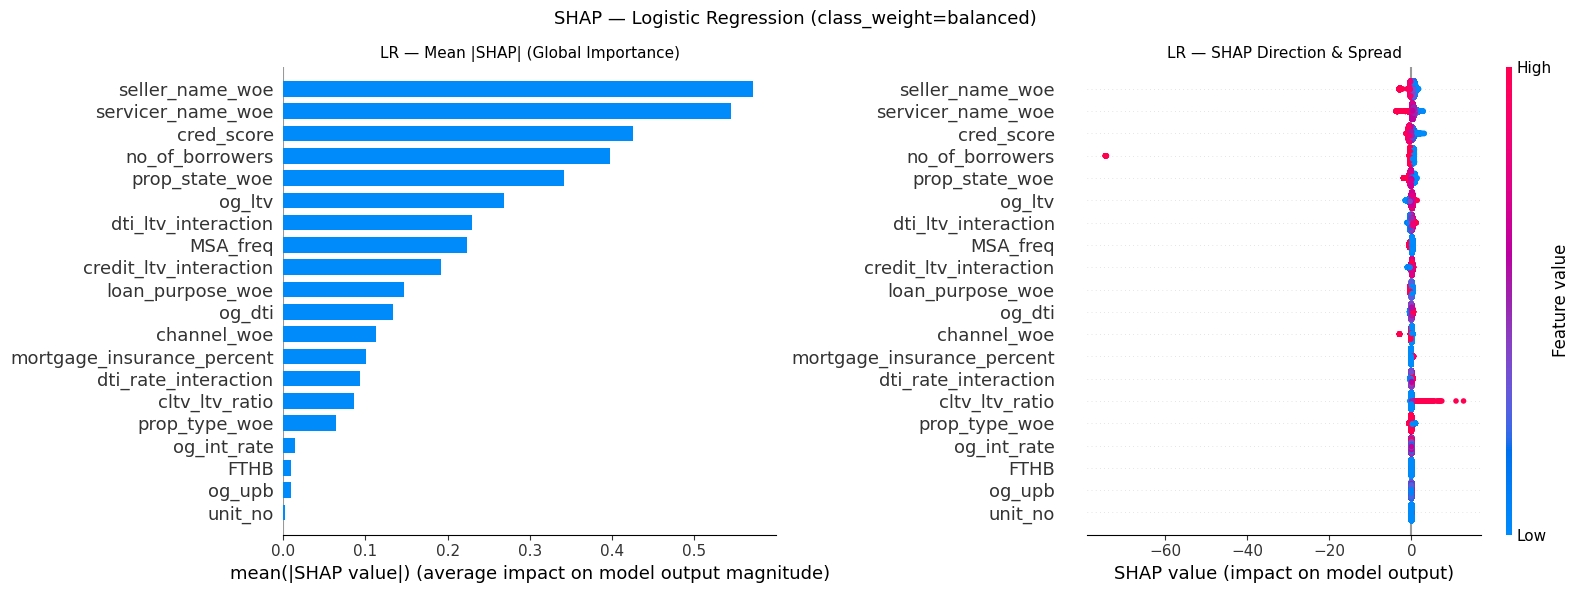

In [23]:
if not SHAP_AVAILABLE:
    print("SHAP not installed. Run: pip install shap")
else:
    # ── SHAP for Logistic Regression (Linear explainer) ────────────────────
    print("Computing SHAP for Logistic Regression...")
    shap.initjs()

    lr_explainer = shap.LinearExplainer(
        lr_cw, X_train,
        feature_perturbation="correlation_dependent"
    )
    # Use val set for SHAP (representative, never re-trained on)
    shap_lr_vals = lr_explainer.shap_values(X_val)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    shap.summary_plot(
        shap_lr_vals, X_val,
        plot_type="bar", show=False,
        plot_size=None
    )
    axes[0].set_title("LR — Mean |SHAP| (Global Importance)", fontsize=11)

    plt.sca(axes[1])
    shap.summary_plot(
        shap_lr_vals, X_val,
        plot_type="dot", show=False,
        plot_size=None
    )
    axes[1].set_title("LR — SHAP Direction & Spread", fontsize=11)

    plt.suptitle("SHAP — Logistic Regression (class_weight=balanced)", fontsize=13)
    plt.tight_layout()
    plt.show()


Computing SHAP for Random Forest (this may take ~1–2 min)...


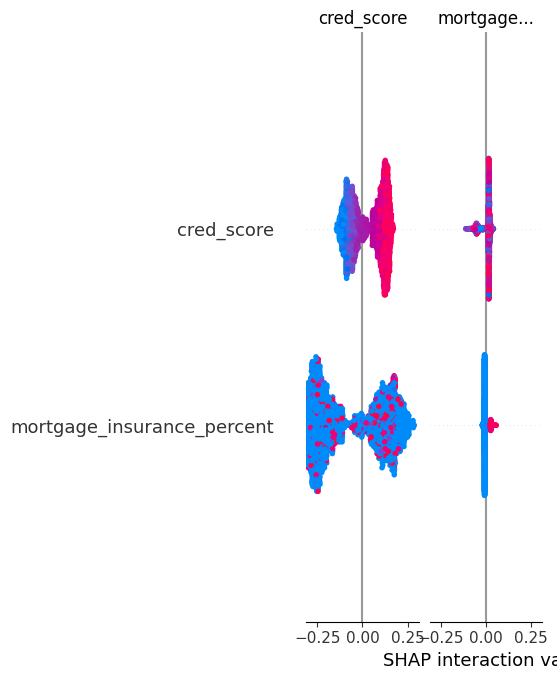

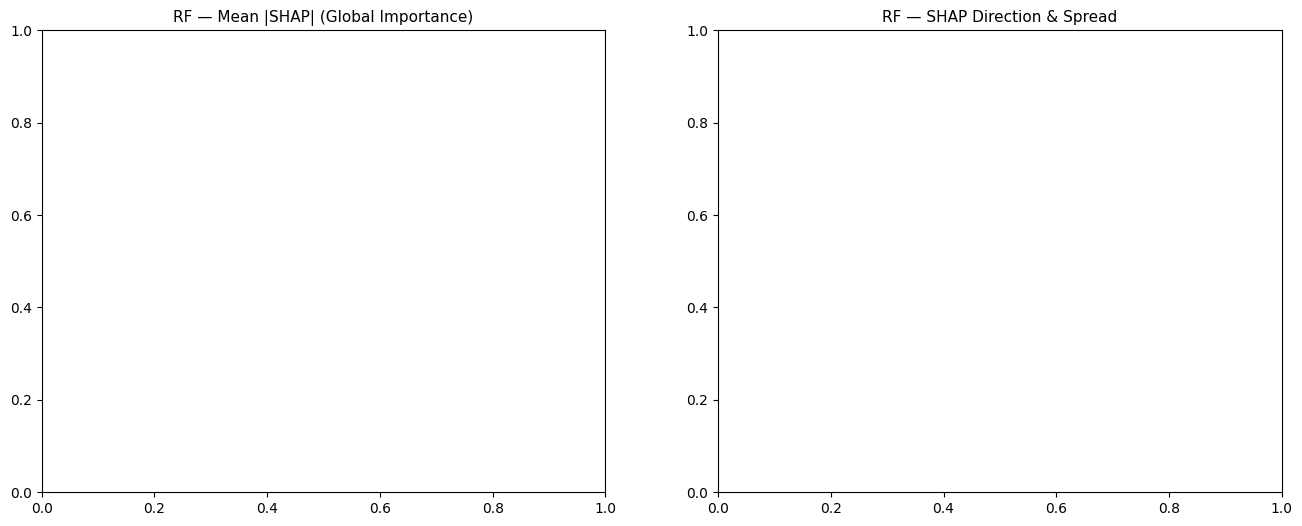

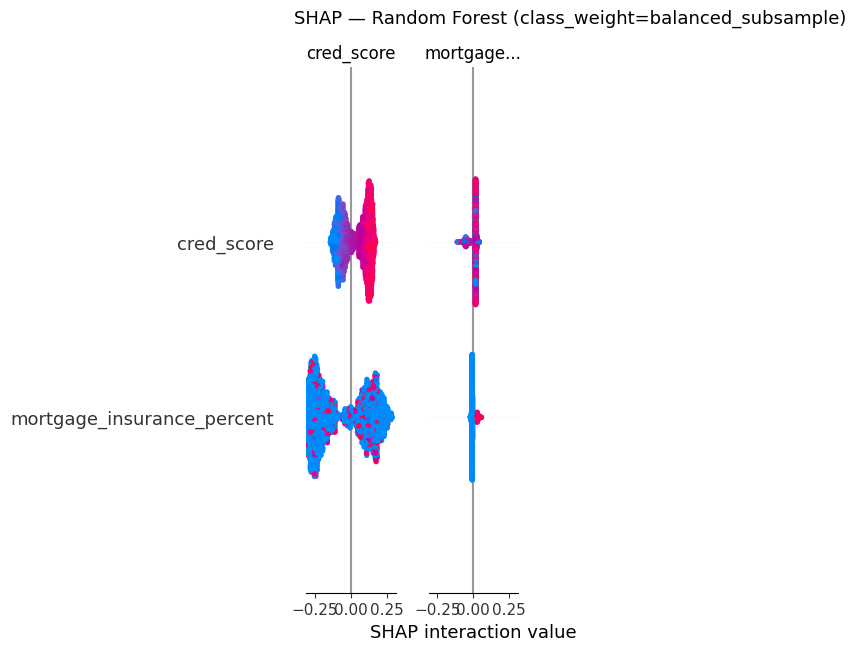

In [24]:
if SHAP_AVAILABLE:
    # ── SHAP for Random Forest (Tree explainer — exact Shapley values) ─────
    print("Computing SHAP for Random Forest (this may take ~1–2 min)...")

    rf_explainer = shap.TreeExplainer(rf, feature_perturbation="tree_path_dependent")

    # Use a stratified subsample of val to keep runtime manageable
    from sklearn.model_selection import StratifiedShuffleSplit
    sss = StratifiedShuffleSplit(n_splits=1, test_size=2000, random_state=42)
    _, shap_idx = next(sss.split(X_val, y_val))
    X_shap_rf  = X_val.iloc[shap_idx].reset_index(drop=True)
    y_shap_rf  = y_val.iloc[shap_idx].reset_index(drop=True)

    shap_rf_vals = rf_explainer.shap_values(X_shap_rf)
    # shap_values returns [class_0, class_1] for classifiers — take class_1 (Default)
    if isinstance(shap_rf_vals, list):
        shap_rf_default = shap_rf_vals[1]
    else:
        shap_rf_default = shap_rf_vals

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    shap.summary_plot(
        shap_rf_default, X_shap_rf,
        plot_type="bar", show=False, plot_size=None
    )
    axes[0].set_title("RF — Mean |SHAP| (Global Importance)", fontsize=11)

    plt.sca(axes[1])
    shap.summary_plot(
        shap_rf_default, X_shap_rf,
        plot_type="dot", show=False, plot_size=None
    )
    axes[1].set_title("RF — SHAP Direction & Spread", fontsize=11)

    plt.suptitle("SHAP — Random Forest (class_weight=balanced_subsample)", fontsize=13)
    plt.tight_layout()
    plt.show()


Computing SHAP for XGBoost...


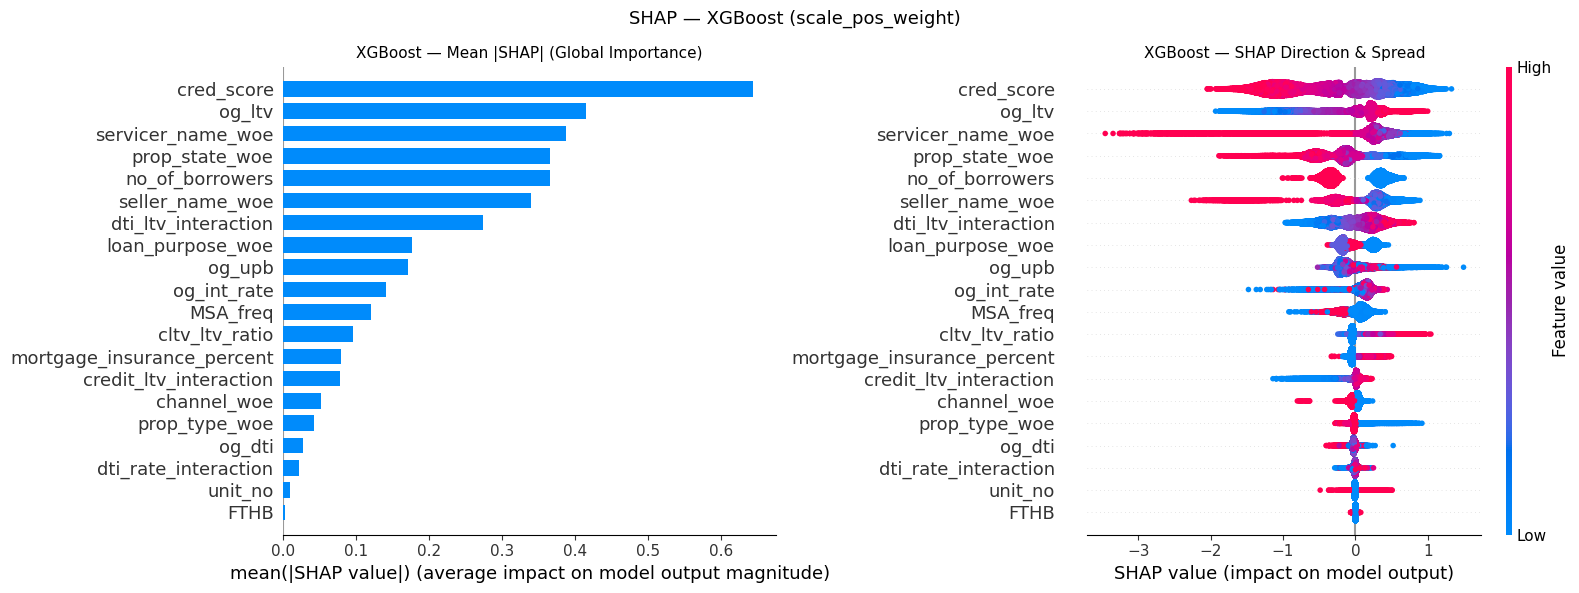

In [25]:
if SHAP_AVAILABLE and XGB_AVAILABLE:
    # ── SHAP for XGBoost (TreeExplainer — fastest) ─────────────────────────
    print("Computing SHAP for XGBoost...")
    xgb_explainer   = shap.TreeExplainer(xgb)
    shap_xgb_vals   = xgb_explainer.shap_values(X_val)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    plt.sca(axes[0])
    shap.summary_plot(shap_xgb_vals, X_val, plot_type="bar", show=False, plot_size=None)
    axes[0].set_title("XGBoost — Mean |SHAP| (Global Importance)", fontsize=11)

    plt.sca(axes[1])
    shap.summary_plot(shap_xgb_vals, X_val, plot_type="dot", show=False, plot_size=None)
    axes[1].set_title("XGBoost — SHAP Direction & Spread", fontsize=11)

    plt.suptitle("SHAP — XGBoost (scale_pos_weight)", fontsize=13)
    plt.tight_layout()
    plt.show()


In [26]:
if SHAP_AVAILABLE:
    # ── SHAP Dependence plots: top 3 features ──────────────────────────────
    # Shows how each feature's effect on PD varies with its value,
    # coloured by the most interacting feature (auto-detected by SHAP).
    mean_abs = np.abs(shap_rf_default).mean(axis=0)
    top3_idx = np.argsort(mean_abs)[::-1][:3]
    top3_features = X_shap_rf.columns[top3_idx].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, feat in zip(axes, top3_features):
        shap.dependence_plot(
            feat, shap_rf_default, X_shap_rf,
            ax=ax, show=False
        )
        ax.set_title(f"SHAP Dependence — {feat}", fontsize=10)
    plt.suptitle("RF SHAP Dependence Plots (top 3 features)", fontsize=13)
    plt.tight_layout()
    plt.show()

    # ── SHAP Waterfall: single loan explanation ─────────────────────────────
    # Pick the highest-predicted-default loan in val set for illustration
    worst_loan_idx = np.argmax(rf.predict_proba(X_val)[:, 1])
    print(f"\nSHAP waterfall for loan index {worst_loan_idx} "
          f"(predicted PD = {rf.predict_proba(X_val)[worst_loan_idx, 1]:.4f}, "
          f"actual = {y_val.iloc[worst_loan_idx]})")

    # Recompute SHAP for this single row
    single_shap = rf_explainer.shap_values(X_val.iloc[[worst_loan_idx]])
    if isinstance(single_shap, list):
        single_shap_default = single_shap[1][0]
    else:
        single_shap_default = single_shap[0]

    explanation = shap.Explanation(
        values=single_shap_default,
        base_values=rf_explainer.expected_value[1] if isinstance(rf_explainer.expected_value, list) else rf_explainer.expected_value,
        data=X_val.iloc[worst_loan_idx].values,
        feature_names=X_val.columns.tolist()
    )
    plt.figure()
    shap.waterfall_plot(explanation, max_display=15, show=True)


ArrowInvalid: only handle 1-dimensional arrays

## Sampling Strategy Comparison (RF only)

Train RF with each sampling strategy and compare Recall, PR-AUC, ROC-AUC on the same (unmodified) val set to isolate the effect of sampling.

In [ ]:
sampling_results = {}

configs = [
    ("RF — class_weight",    X_train,       y_train,       {"class_weight": "balanced_subsample"}),
    ("RF — SMOTE",           X_train_smote, y_train_smote, {}),
    ("RF — ADASYN",          X_train_adasyn,y_train_adasyn,{}),
]

for name, Xtr, ytr, extra_kwargs in configs:
    m = RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=100,
        random_state=42, n_jobs=-1, **extra_kwargs
    )
    m.fit(Xtr, ytr)
    y_prob = m.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    sampling_results[name] = {
        "Recall"   : recall_score(y_val, y_pred, zero_division=0),
        "Precision": precision_score(y_val, y_pred, zero_division=0),
        "F1"       : f1_score(y_val, y_pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y_val, y_prob),
        "PR-AUC"   : average_precision_score(y_val, y_prob),
    }

samp_df = pd.DataFrame(sampling_results).T
print(samp_df.round(4).to_string())

samp_df[["Recall","Precision","F1","ROC-AUC","PR-AUC"]].plot(
    kind="bar", figsize=(12, 5), edgecolor="white"
)
plt.title("Sampling Strategy Comparison (Random Forest — Val Set)")
plt.ylabel("Score"); plt.xticks(rotation=15)
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

print("\n> For IFRS-9: prefer the strategy with highest Recall and PR-AUC.")
print("> A precision-recall tradeoff is expected — model selection should")
print("> consider the business cost of missed defaults vs false alarms.")


## Final Test-Set Evaluation

> **Run this cell only once** — after model and sampling strategy are selected from the val results above. Re-tuning based on test metrics = test-set leakage.

Change `best_model` / `best_model_name` to whichever won on val.

In [ ]:
# ── Replace with your best model from val comparison ─────────────────────────
best_model      = rf             # ← change after reviewing val results
best_model_name = "Random Forest"

print(f"Final evaluation: {best_model_name} on held-out TEST set")
test_metrics = evaluate(
    best_model, X_test, y_test,
    model_name=best_model_name + " [TEST]",
    split_name="Test",
    store=False
)


In [ ]:
if SHAP_AVAILABLE:
    # ── SHAP force plot: 5 individual loan explanations on test set ─────────
    # Useful for IFRS-9 model documentation and individual obligor reporting
    top5_idx = np.argsort(best_model.predict_proba(X_test)[:, 1])[::-1][:5]
    single_shap_test = rf_explainer.shap_values(X_test.iloc[top5_idx])
    if isinstance(single_shap_test, list):
        single_shap_test = single_shap_test[1]
    ev = rf_explainer.expected_value
    if isinstance(ev, list): ev = ev[1]

    print("SHAP force plots — 5 highest-PD loans in test set:")
    for i, (idx, sv) in enumerate(zip(top5_idx, single_shap_test)):
        pred_pd = best_model.predict_proba(X_test)[[idx], 1][0]
        exp = shap.Explanation(
            values=sv,
            base_values=ev,
            data=X_test.iloc[idx].values,
            feature_names=X_test.columns.tolist()
        )
        print(f"\nLoan {i+1} (test idx={idx}) — Predicted PD: {pred_pd:.4f}, Actual: {y_test.iloc[idx]}")
        shap.waterfall_plot(exp, max_display=12, show=True)
